<a href="https://colab.research.google.com/github/tessemadonnam-cmd/predictive-maintenance-system/blob/main/Predictive_Maintenance_for_Manufacturing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  

Dataset Shape:
(10000, 10)

Column Names:
Index(['UDI', 'Product ID', 'Type',

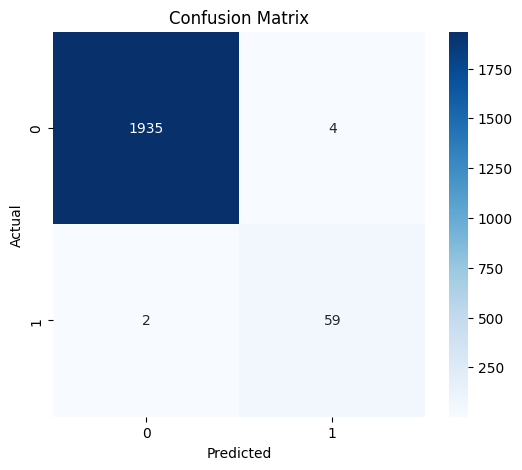


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       0.94      0.97      0.95        61

    accuracy                           1.00      2000
   macro avg       0.97      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000


Prediction Result:
Normal Operation


In [7]:
# =====================================================
# PREDICTIVE MAINTENANCE USING MACHINE LEARNING
# =====================================================

# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =====================================================
# STEP 2: LOAD DATASET
# =====================================================

url = "https://raw.githubusercontent.com/tessemadonnam-cmd/predictive-maintenance-system/main/predictive_maintenance.csv"

df = pd.read_csv(url)

# =====================================================
# STEP 3: DISPLAY DATASET
# =====================================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

# =====================================================
# STEP 4: REMOVE UNNECESSARY COLUMNS
# =====================================================

if "UDI" in df.columns:
    df.drop("UDI", axis=1, inplace=True)

if "Product ID" in df.columns:
    df.drop("Product ID", axis=1, inplace=True)

# =====================================================
# STEP 5: ENCODE CATEGORICAL COLUMNS
# =====================================================

le = LabelEncoder()

# Convert Type column into numbers
if "Type" in df.columns:
    df["Type"] = le.fit_transform(df["Type"])

# Convert Failure Type column into numbers
if "Failure Type" in df.columns:
    df["Failure Type"] = le.fit_transform(df["Failure Type"])

# =====================================================
# STEP 6: DEFINE INPUT AND OUTPUT
# =====================================================

X = df.drop("Target", axis=1)

y = df["Target"]

# =====================================================
# STEP 7: SPLIT DATASET
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# STEP 8: TRAIN MODEL
# =====================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# STEP 9: MAKE PREDICTIONS
# =====================================================

y_pred = model.predict(X_test)

# =====================================================
# STEP 10: MODEL ACCURACY
# =====================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(round(accuracy * 100, 2), "%")

# =====================================================
# STEP 11: CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# =====================================================
# STEP 12: CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =====================================================
# STEP 13: SAMPLE PREDICTION
# =====================================================

sample = X_test.iloc[0:1]

prediction = model.predict(sample)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Machine Failure Likely")
else:
    print("Normal Operation")